# Mealy-Automat: Cola-Fanta-Automat

Ein endlicher Zustandsautomat vom Typ **Mealy**, bei dem die Ausgabe jeweils von
Zustand *und* Eingabe abhängt (nicht nur vom Zustand wie bei Moore).

## Formale Definition

$$\mathcal{A} = (S,\, \Sigma,\, \Delta,\, \delta,\, \lambda,\, s_0)$$

| Komponente | Bedeutung | Wert |
|---|---|---|
| $S$ | Zustandsmenge | $\{s_0, s_1, s_2\}$ |
| $\Sigma$ | Eingabealphabet | $\{\text{coin},\, \text{cola},\, \text{fanta}\}$ |
| $\Delta$ | Ausgabealphabet | $\{\text{—, }\text{1 euro eingeworfen},\, \text{2 euro eingeworfen},\, \text{cola},\, \text{fanta}\}$ |
| $\delta$ | Überführungsfunktion $S\times\Sigma \to S$ | siehe Tabelle |
| $\lambda$ | Ausgabefunktion $S\times\Sigma \to \Delta$ (Mealy!) | siehe Tabelle |
| $s_0$ | Startzustand | $s_0$ |

### Zustandssemantik
- **$s_0$** – idle: 0 € eingeworfen
- **$s_1$** – 1 € eingeworfen (Display: „1 euro eingeworfen“)
- **$s_2$** – 2 € eingeworfen (Display: „2 euro eingeworfen“, bereit zur Wahl)

### Festlegungen (Designentscheidungen)
- Nur **1 €-Münzen**; nach Erreichen von $s_2$ wird weiterer Münzeinwurf ignoriert (keine Überzahlung).
- Tastendruck `cola`/`fanta` *vor* $s_2$ wird **ignoriert** (keine Zustandsänderung, Ausgabe „—“).
- Nach Getränkeausgabe **automatische Rückkehr** in $s_0$; **keine Stornotaste**.

## Zustands-Übergangs-Tabelle

| Zustand | Input | Folgezustand $\delta$ | Ausgabe $\lambda$ |
|:---:|:---:|:---:|:---|
| $s_0$ | `coin`  | $s_1$ | 1 euro eingeworfen |
| $s_0$ | `cola`  | $s_0$ | — |
| $s_0$ | `fanta` | $s_0$ | — |
| $s_1$ | `coin`  | $s_2$ | 2 euro eingeworfen |
| $s_1$ | `cola`  | $s_1$ | — |
| $s_1$ | `fanta` | $s_1$ | — |
| $s_2$ | `coin`  | $s_2$ | — |
| $s_2$ | `cola`  | $s_0$ | cola |
| $s_2$ | `fanta` | $s_0$ | fanta |

## Implementierung der Überführungs- und Ausgabefunktion

Die Tabelle wird direkt als verschachteltes Dictionary codiert:
`ÜBERGÄNGE[zustand][input] = (folgezustand, ausgabe)`.

In [1]:
STATES = ["s0", "s1", "s2"]
INPUTS = ["coin", "cola", "fanta"]
START = "s0"

# (folgezustand, ausgabe) für jeden (Zustand, Input)-Paar – Mealy
UEBERGAENGE = {
    "s0": {
        "coin":  ("s1", "1 euro eingeworfen"),
        "cola":  ("s0", "—"),
        "fanta": ("s0", "—"),
    },
    "s1": {
        "coin":  ("s2", "2 euro eingeworfen"),
        "cola":  ("s1", "—"),
        "fanta": ("s1", "—"),
    },
    "s2": {
        "coin":  ("s2", "—"),          # Überzahlung ignoriert
        "cola":  ("s0", "cola"),      # Ausgabe + Auto-Rückkehr
        "fanta": ("s0", "fanta"),
    },
}

def delta(zustand, inp):
    """Überführungsfunktion δ."""
    return UEBERGAENGE[zustand][inp][0]

def lam(zustand, inp):
    """Ausgabefunktion λ (Mealy: abhängig von Zustand UND Eingabe)."""
    return UEBERGAENGE[zustand][inp][1]

## Zustandsdiagramm

Mit `graphviz` werden alle Übergänge als Kanten beschriftet mit `Input / Ausgabe`
(typische Mealy-Notation).

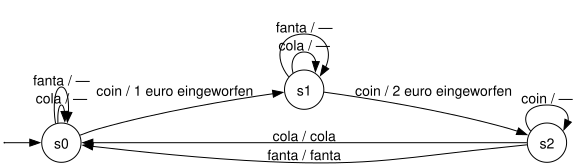

In [2]:
from graphviz import Digraph

g = Digraph("mealy-cola-fanta", format="svg")
g.attr(rankdir="LR")
g.attr("node", shape="circle", fontname="Helvetica")
g.attr("edge", fontname="Helvetica")

# Start-Pfeil
g.node("start", shape="point", width="0")
g.edge("start", START)

# Zustände
for s in STATES:
    g.node(s, s)

# Übergänge (Input / Ausgabe) – Schleifen für ignorierte Eingaben nur,
# wenn erhältlich Sinn ergeben; hier kompakt als Schleifen gezeichnet.
seen_edges = set()
for s in STATES:
    for inp, (s2, out) in UEBERGAENGE[s].items():
        # Ignorierte Eingaben als Schleife, sonst normale Kante
        label = f"{inp} / {out}"
        key = (s, s2)
        # Mehrere Eingaben zwischen denselben Knoten werden gestapelt
        if key in seen_edges:
            g.edge(s, s2, label=label)
        else:
            g.edge(s, s2, label=label)
            seen_edges.add(key)

g

## Schritt-für-Schritt-Simulator

Kleine Klasse, die den aktuellen Zustand speichert und für jede Eingabe die
Mealy-Ausgabe sowie den Folgezustand liefert.

In [3]:
class MealyAutomat:
    def __init__(self, uebergaenge, start):
        self.uebergaenge = uebergaenge
        self.zustand = start
        self.start = start

    def step(self, inp):
        folge, ausgabe = self.uebergaenge[self.zustand][inp]
        self.zustand = folge
        return ausgabe

    def run(self, eingaben):
        print(f"Start: {self.zustand}")
        for i, inp in enumerate(eingaben, 1):
            ausgabe = self.step(inp)
            print(f"  {i}. Input={inp:<6} -> Ausgabe={ausgabe:<20} | Zustand nun: {self.zustand}")
        print(f"Ende: {self.zustand}\n")

automat = MealyAutomat(UEBERGAENGE, START)

## Demo-Sequenzen

1. **Korrekte Cola-Bestellung**
2. **Versuchte Wahl zu früh + anschließende Fanta-Bestellung**
3. **Überzahlung ignorieren + Fanta**

In [4]:
print("=== Sequenz 1: 1€ + 1€ + cola ===")
MealyAutomat(UEBERGAENGE, START).run(["coin", "coin", "cola"])

print("=== Sequenz 2: cola (zu früh) + 1€ + cola (zu früh) + 1€ + fanta ===")
MealyAutomat(UEBERGAENGE, START).run(["cola", "coin", "cola", "coin", "fanta"])

print("=== Sequenz 3: 1€ + (1€ -> in s2, dann noch coin: ignoriert) + fanta ===")
MealyAutomat(UEBERGAENGE, START).run(["coin", "coin", "coin", "fanta"])

=== Sequenz 1: 1€ + 1€ + cola ===
Start: s0
  1. Input=coin   -> Ausgabe=1 euro eingeworfen   | Zustand nun: s1
  2. Input=coin   -> Ausgabe=2 euro eingeworfen   | Zustand nun: s2
  3. Input=cola   -> Ausgabe=cola                 | Zustand nun: s0
Ende: s0

=== Sequenz 2: cola (zu früh) + 1€ + cola (zu früh) + 1€ + fanta ===
Start: s0
  1. Input=cola   -> Ausgabe=—                    | Zustand nun: s0
  2. Input=coin   -> Ausgabe=1 euro eingeworfen   | Zustand nun: s1
  3. Input=cola   -> Ausgabe=—                    | Zustand nun: s1
  4. Input=coin   -> Ausgabe=2 euro eingeworfen   | Zustand nun: s2
  5. Input=fanta  -> Ausgabe=fanta                | Zustand nun: s0
Ende: s0

=== Sequenz 3: 1€ + (1€ -> in s2, dann noch coin: ignoriert) + fanta ===
Start: s0
  1. Input=coin   -> Ausgabe=1 euro eingeworfen   | Zustand nun: s1
  2. Input=coin   -> Ausgabe=2 euro eingeworfen   | Zustand nun: s2
  3. Input=coin   -> Ausgabe=—                    | Zustand nun: s2
  4. Input=fanta  -> Ausga